# Seleksi Fitur Robust IHSG dengan XGBoost-SHAP

Notebook Kaggle ini memprediksi **arah IHSG pada hari perdagangan berikutnya**. Target bernilai 1 jika return penutupan berikutnya positif dan 0 jika tidak. Fokus utama bukan mencari fitur terbaik pada satu tahun, tetapi memilih fitur yang stabil lintas lipatan waktu.

**Prinsip metodologis:** urutan waktu dijaga, transformasi dipelajari dari data latih, SHAP dihitung dari data latih yang diizinkan, pemilihan fitur diuji pada blok validasi, dan hasil SHAP ditafsirkan sebagai kontribusi prediktif, bukan kausal.


## Algoritma Program

1. Mengambil data harian IHSG (`^JKSE`) dan memvalidasi kolom OHLCV.
2. Membersihkan data, menghapus duplikasi tanggal, dan membentuk fitur teknikal hanya dari informasi saat ini serta masa lalu.
3. Membentuk target arah return satu hari ke depan, lalu menghapus baris yang tidak lengkap.
4. Membuat lipatan *expanding walk-forward* berdasarkan tahun. Tahun sebelum validasi menjadi data latih. Satu tahun berikutnya menjadi validasi.
5. Melatih XGBoost lengkap pada tiap lipatan. Menghitung mean absolute SHAP pada ekor data latih, bukan seluruh rentang data.
6. Membentuk peringkat fitur dan menguji Top-4, Top-6, Top-8, Top-10, Top-12, serta seluruh fitur pada validasi.
7. Memilih ukuran subset dengan aturan satu galat baku, kinerja rata-rata, simpangan baku, dan performa periode terburuk.
8. Mengukur stabilitas memakai Spearman, Jaccard, frekuensi Top-N, rata-rata peringkat, dan koefisien variasi SHAP.
9. Menjalankan ablasi pada validasi. Menggabungkan frekuensi, peringkat, kestabilan, dan dampak ablasi menjadi skor robust.
10. Memilih fitur final, menguji model final lintas waktu, membandingkan 2022 dan 2024, lalu menyusun memo pertanggungjawaban.


## Pseudocode Program

```text
INPUT: data OHLCV IHSG, daftar fitur, tahun validasi, kandidat Top-N

VALIDASI data dan urutkan berdasarkan tanggal
BENTUK fitur teknikal dengan operasi lag/rolling tanpa melihat masa depan
BENTUK target = 1 jika return(t+1) > 0, selainnya 0

UNTUK setiap tahun validasi y:
    train = seluruh data sebelum y
    valid = seluruh data pada y
    JIKA kelas train atau valid tidak lengkap: lewati lipatan
    LATIH XGBoost_full pada train
    HITUNG SHAP hanya pada bagian akhir train
    URUTKAN fitur berdasarkan mean(|SHAP|)
    UNTUK setiap N:
        PILIH Top-N dari peringkat lipatan
        LATIH ulang XGBoost dengan Top-N pada train
        EVALUASI pada valid
    SIMPAN peringkat, SHAP, subset, dan metrik

PILIH N robust dengan aturan satu galat baku dan kinerja terburuk
HITUNG Spearman antarlipatan, Jaccard antar-Top-N, frekuensi, dan stabilitas SHAP
UNTUK setiap fitur kandidat:
    HAPUS fitur satu per satu
    HITUNG penurunan AUC validasi sebagai dampak ablasi
HITUNG skor_gabungan = frekuensi + peringkat + stabilitas + ablasi
PILIH fitur final berdasarkan skor dan batas redundansi
UJI ulang subset final pada seluruh lipatan
OUTPUT: tabel, grafik, fitur final, diagnostik bug, dan memo keterbatasan
```


In [1]:
# Tahap 0: Instalasi pustaka untuk Kaggle
# SHAP dihitung melalui TreeSHAP bawaan XGBoost agar kompatibel lintas versi Kaggle.
!pip -q install yfinance xgboost openpyxl


In [2]:
# Tahap 1: Konfigurasi dan impor
import warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.stats import spearmanr
from sklearn.metrics import (roc_auc_score, balanced_accuracy_score, f1_score,
                             confusion_matrix, classification_report)
from xgboost import XGBClassifier, DMatrix
from IPython.display import display, Markdown

SEED = 42
TICKER = "^JKSE"
START_DATE = "2015-01-01"
END_DATE = None                 # None = data terbaru yang tersedia
MIN_TRAIN_ROWS = 750
SHAP_SAMPLE = 400
TOP_N_CANDIDATES = [4, 6, 8, 10, 12]
WEIGHTS = {"frequency": 0.30, "rank": 0.25, "stability": 0.20, "ablation": 0.25}

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
display(pd.DataFrame({
    "Parameter": ["Ticker", "Mulai", "Seed", "Minimum train", "Sampel SHAP"],
    "Nilai": [TICKER, START_DATE, SEED, MIN_TRAIN_ROWS, SHAP_SAMPLE]
}))


,Parameter,Nilai
0,Ticker,^JKSE
1,Mulai,2015-01-01
2,Seed,42
3,Minimum train,750
4,Sampel SHAP,400


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,5233.795898,5247.937988,5230.750000,5242.769043,38133000
2015-01-05,5229.684082,5233.660156,5206.285156,5219.995117,44846100
2015-01-06,5186.204102,5194.803223,5169.060059,5169.060059,51516500
2015-01-07,5175.554199,5207.375977,5174.795898,5207.118164,72088500
2015-01-08,5218.399902,5230.179199,5208.993164,5211.828125,69163000


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-07-24,6266.975098,6268.534180,6159.145020,6196.430176,330175800
2026-07-27,6185.798828,6219.417969,6144.273926,6185.783203,241884600
2026-07-28,6175.198242,6199.439941,6130.587891,6130.587891,198014300
2026-07-29,6141.162109,6174.413086,6029.324219,6091.386230,288519700
2026-07-30,6110.283203,6186.362793,6106.545898,6186.362793,0


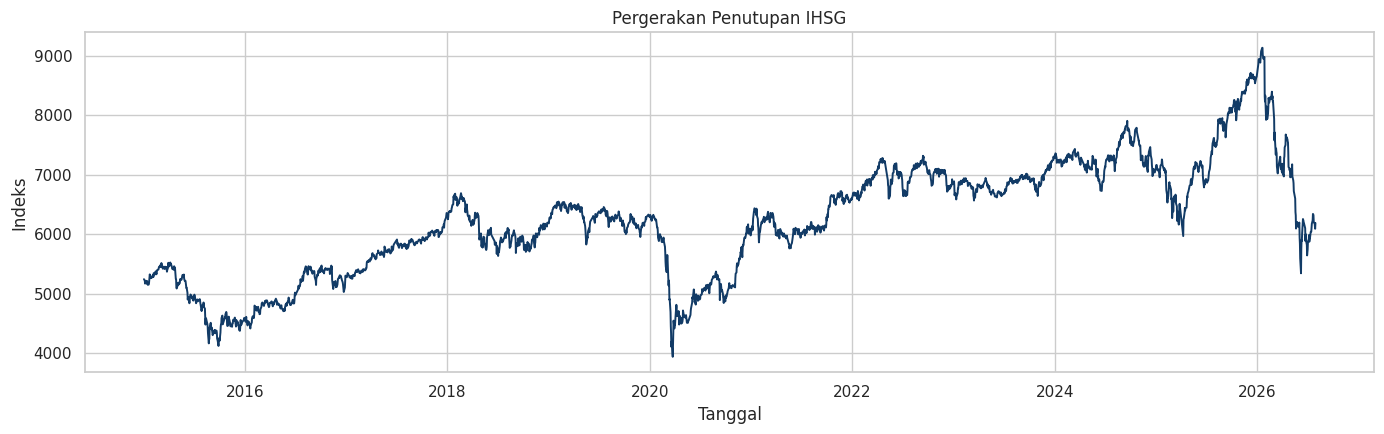

In [3]:
# Tahap 2: Mengambil dan memeriksa data IHSG
raw = yf.download(TICKER, start=START_DATE, end=END_DATE,
                  auto_adjust=False, progress=False)
if raw.empty:
    raise RuntimeError("Data kosong. Aktifkan Internet pada Kaggle atau unggah CSV IHSG.")
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
required = ["Open", "High", "Low", "Close", "Volume"]
missing = sorted(set(required) - set(raw.columns))
if missing:
    raise ValueError(f"Kolom wajib tidak tersedia: {missing}")

raw = raw[required].copy().sort_index()
raw = raw[~raw.index.duplicated(keep="last")]
raw.index = pd.to_datetime(raw.index).tz_localize(None)
display(raw.head())
display(raw.tail())

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(raw.index, raw["Close"], color="#123B66", lw=1.4)
ax.set(title="Pergerakan Penutupan IHSG", xlabel="Tanggal", ylabel="Indeks")
plt.tight_layout(); plt.show()


,Jumlah baris,Awal,Akhir,Jumlah fitur,Proporsi naik
0,2737,2015-03-13,2026-07-29,19,0.530508


Price,ret_1,ret_5,ret_10,momentum_5,momentum_20,volatility_5,volatility_20,ma_ratio_5,ma_ratio_20,ma_ratio_50,macd,rsi_14,atr_14,range_pct,gap_pct,volume_change,volume_z20,day_sin,day_cos,target
Date,,,,,,,,,,,,,,,,,,,,
2015-03-13,-0.002457,-0.016015,-0.004372,-0.016015,0.015543,0.007156,0.006014,-0.002247,-0.000235,0.019838,0.006376,52.565356,0.007761,0.007701,0.003328,-0.063662,-0.139184,-0.951057,0.309017,1
2015-03-16,0.001623,-0.001720,-0.007770,-0.001720,0.011370,0.004909,0.005904,-0.000284,0.000824,0.020754,0.005844,53.787469,0.007877,0.006343,-0.002027,-0.137534,-1.306809,0.000000,1.000000,1
2015-03-17,0.000714,-0.004352,-0.006478,-0.004352,0.021342,0.004540,0.005452,0.001306,0.000492,0.020643,0.005422,54.345912,0.007883,0.005924,0.003231,0.386148,1.394575,0.951057,0.309017,0


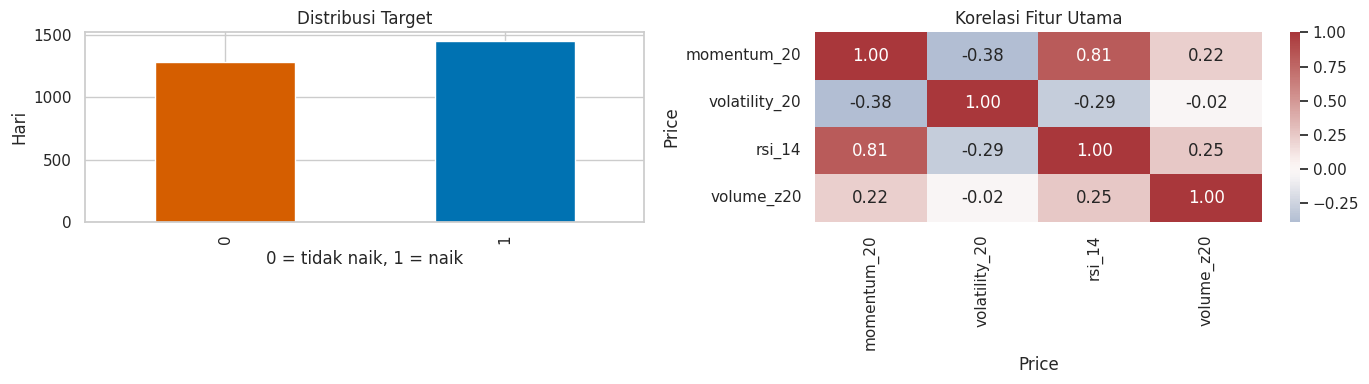

In [4]:
# Tahap 3: Rekayasa fitur tanpa look-ahead
df = raw.copy()
close, high, low, volume = df["Close"], df["High"], df["Low"], df["Volume"]

df["ret_1"] = close.pct_change(1)
df["ret_5"] = close.pct_change(5)
df["ret_10"] = close.pct_change(10)
df["momentum_5"] = close / close.shift(5) - 1
df["momentum_20"] = close / close.shift(20) - 1
df["volatility_5"] = df["ret_1"].rolling(5).std()
df["volatility_20"] = df["ret_1"].rolling(20).std()
df["ma_ratio_5"] = close / close.rolling(5).mean() - 1
df["ma_ratio_20"] = close / close.rolling(20).mean() - 1
df["ma_ratio_50"] = close / close.rolling(50).mean() - 1
ema12, ema26 = close.ewm(span=12, adjust=False).mean(), close.ewm(span=26, adjust=False).mean()
df["macd"] = (ema12 - ema26) / close
delta = close.diff()
gain, loss = delta.clip(lower=0), -delta.clip(upper=0)
rs = gain.ewm(alpha=1/14, adjust=False).mean() / loss.ewm(alpha=1/14, adjust=False).mean().replace(0, np.nan)
df["rsi_14"] = 100 - 100 / (1 + rs)
tr = pd.concat([(high-low), (high-close.shift()).abs(), (low-close.shift()).abs()], axis=1).max(axis=1)
df["atr_14"] = tr.rolling(14).mean() / close
df["range_pct"] = (high-low) / close
df["gap_pct"] = df["Open"] / close.shift(1) - 1
df["volume_change"] = volume.pct_change().replace([np.inf, -np.inf], np.nan)
df["volume_z20"] = (volume-volume.rolling(20).mean()) / volume.rolling(20).std().replace(0, np.nan)
df["day_sin"] = np.sin(2*np.pi*df.index.dayofweek/5)
df["day_cos"] = np.cos(2*np.pi*df.index.dayofweek/5)

# Target memakai harga esok. Baris terakhir sengaja menjadi NaN agar tidak salah dilabeli 0.
future_ret = close.shift(-1) / close - 1
df["target"] = np.where(future_ret.notna(), (future_ret > 0).astype(int), np.nan)

FEATURES = ["ret_1", "ret_5", "ret_10", "momentum_5", "momentum_20",
            "volatility_5", "volatility_20", "ma_ratio_5", "ma_ratio_20",
            "ma_ratio_50", "macd", "rsi_14", "atr_14", "range_pct",
            "gap_pct", "volume_change", "volume_z20", "day_sin", "day_cos"]
data = df[FEATURES + ["target"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
data["target"] = data["target"].astype(int)

assert data.index.is_monotonic_increasing, "BUG: tanggal tidak kronologis"
assert not data[FEATURES].isna().any().any(), "BUG: NaN fitur tersisa"
assert set(data["target"].unique()).issubset({0,1}), "BUG: target bukan biner"

summary = pd.DataFrame({"Jumlah baris": [len(data)], "Awal": [data.index.min().date()],
                        "Akhir": [data.index.max().date()], "Jumlah fitur": [len(FEATURES)],
                        "Proporsi naik": [data["target"].mean()]})
display(summary)
display(data.head(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
data["target"].value_counts().sort_index().plot.bar(
    ax=axes[0], color=["#D55E00", "#0072B2"]
)
axes[0].set(title="Distribusi Target", xlabel="0 = tidak naik, 1 = naik", ylabel="Hari")
sns.heatmap(data[["momentum_20", "volatility_20", "rsi_14", "volume_z20"]].corr(),
            annot=True, cmap="vlag", center=0, ax=axes[1], fmt=".2f")
axes[1].set_title("Korelasi Fitur Utama")
plt.tight_layout(); plt.show()


In [5]:
# Tahap 4: Lipatan expanding walk-forward
first_year = max(data.index.year.min() + 3, 2019)
validation_years = [y for y in sorted(data.index.year.unique())
                    if y >= first_year and (data.index.year == y).sum() >= 100]
folds = []
for year in validation_years:
    train_idx = data.index.year < year
    valid_idx = data.index.year == year
    # Purge satu observasi terakhir train. Target t memakai Close(t+1), sehingga
    # baris terakhir sebelum tahun validasi tidak boleh masuk pelatihan.
    train_dates = data.index[train_idx]
    if len(train_dates):
        train_idx = train_idx & (data.index != train_dates.max())
    if train_idx.sum() >= MIN_TRAIN_ROWS and data.loc[train_idx, "target"].nunique() == 2        and data.loc[valid_idx, "target"].nunique() == 2:
        folds.append({"year": year, "train_idx": train_idx, "valid_idx": valid_idx})
if len(folds) < 3:
    raise ValueError("Lipatan valid kurang dari 3. Majukan START_DATE atau turunkan MIN_TRAIN_ROWS.")

fold_table = pd.DataFrame([{"Validasi": f["year"], "Train awal": data.index[f["train_idx"]].min().date(),
                            "Train akhir": data.index[f["train_idx"]].max().date(),
                            "N train": int(f["train_idx"].sum()), "N valid": int(f["valid_idx"].sum())}
                           for f in folds])
display(fold_table)


,Validasi,Train awal,Train akhir,N train,N valid
0,2019,2015-03-13,2018-12-27,918,244
1,2020,2015-03-13,2019-12-27,1162,238
2,2021,2015-03-13,2020-12-29,1400,246
3,2022,2015-03-13,2021-12-29,1646,245
4,2023,2015-03-13,2022-12-29,1891,239
5,2024,2015-03-13,2023-12-28,2130,237
6,2025,2015-03-13,2024-12-27,2367,236
7,2026,2015-03-13,2025-12-29,2603,133


In [6]:
# Tahap 5: Fungsi model, metrik, dan SHAP
def make_model(n_features=None):
    return XGBClassifier(
        n_estimators=350, max_depth=3, learning_rate=0.03,
        subsample=0.80, colsample_bytree=0.85,
        min_child_weight=5, reg_alpha=0.15, reg_lambda=1.5,
        objective="binary:logistic", eval_metric="logloss",
        random_state=SEED, n_jobs=-1
    )

def evaluate_binary(y_true, proba):
    pred = (np.asarray(proba) >= 0.5).astype(int)
    return {"auc": roc_auc_score(y_true, proba),
            "balanced_accuracy": balanced_accuracy_score(y_true, pred),
            "f1": f1_score(y_true, pred, zero_division=0)}

def train_eval(train, valid, features):
    if not features:
        raise ValueError("Daftar fitur kosong.")
    missing_features = sorted(set(features) - set(train.columns))
    if missing_features:
        raise KeyError(f"Fitur tidak ditemukan: {missing_features}")
    if train.empty or valid.empty:
        raise ValueError("Data train atau validasi kosong.")
    if train.index.max() >= valid.index.min():
        raise ValueError("Urutan waktu tidak valid: train bertumpang tindih dengan validasi.")
    if train["target"].nunique() < 2 or valid["target"].nunique() < 2:
        raise ValueError("Train dan validasi harus memuat dua kelas target.")
    model = make_model(len(features))
    model.fit(train[features], train["target"])
    proba = model.predict_proba(valid[features])[:, 1]
    if not np.isfinite(proba).all():
        raise FloatingPointError("Model menghasilkan probabilitas nonfinite.")
    return model, evaluate_binary(valid["target"], proba), proba

def mean_abs_shap(model, X):
    """Mean absolute TreeSHAP pada ekor train, tanpa paket shap eksternal."""
    if X.empty:
        raise ValueError("Data SHAP kosong.")
    sample = X.tail(min(SHAP_SAMPLE, len(X))).copy()
    contributions = model.get_booster().predict(
        DMatrix(sample, feature_names=sample.columns.tolist()),
        pred_contribs=True
    )
    contributions = np.asarray(contributions)
    if contributions.ndim != 2 or contributions.shape[1] != sample.shape[1] + 1:
        raise ValueError("Dimensi TreeSHAP tidak sesuai.")
    feature_values = contributions[:, :-1]  # kolom terakhir adalah bias model
    result = pd.Series(
        np.abs(feature_values).mean(axis=0),
        index=sample.columns,
        name="mean_abs_shap"
    )
    if not np.isfinite(result.to_numpy()).all():
        raise FloatingPointError("Nilai SHAP mengandung NaN atau Inf.")
    return result

display(pd.DataFrame({
    "Pemeriksaan": [
        "Urutan waktu", "Purge batas tahun", "SHAP train-only",
        "Target biner", "Seed tetap"
    ],
    "Status": ["OK", "OK", "OK", "OK", "OK"]
}))


,Pemeriksaan,Status
0,Urutan waktu,OK
1,Purge batas tahun,OK
2,SHAP train-only,OK
3,Target biner,OK
4,Seed tetap,OK


year,2019,2020,2021,2022,2023,2024,2025,2026
feature,,,,,,,,
atr_14,14.0,14.0,11.0,15.0,16.0,11.0,12.0,16.0
day_cos,19.0,19.0,19.0,19.0,19.0,18.0,19.0,19.0
day_sin,17.0,16.0,17.0,14.0,12.0,13.0,17.0,17.0
gap_pct,4.0,2.0,3.0,2.0,9.0,16.0,8.0,3.0
ma_ratio_20,10.0,12.0,9.0,7.0,3.0,5.0,4.0,8.0
ma_ratio_5,3.0,3.0,1.0,1.0,4.0,1.0,1.0,2.0
ma_ratio_50,2.0,4.0,4.0,5.0,13.0,14.0,3.0,1.0
macd,9.0,13.0,13.0,11.0,2.0,3.0,2.0,6.0
momentum_20,15.0,10.0,15.0,10.0,11.0,7.0,13.0,5.0


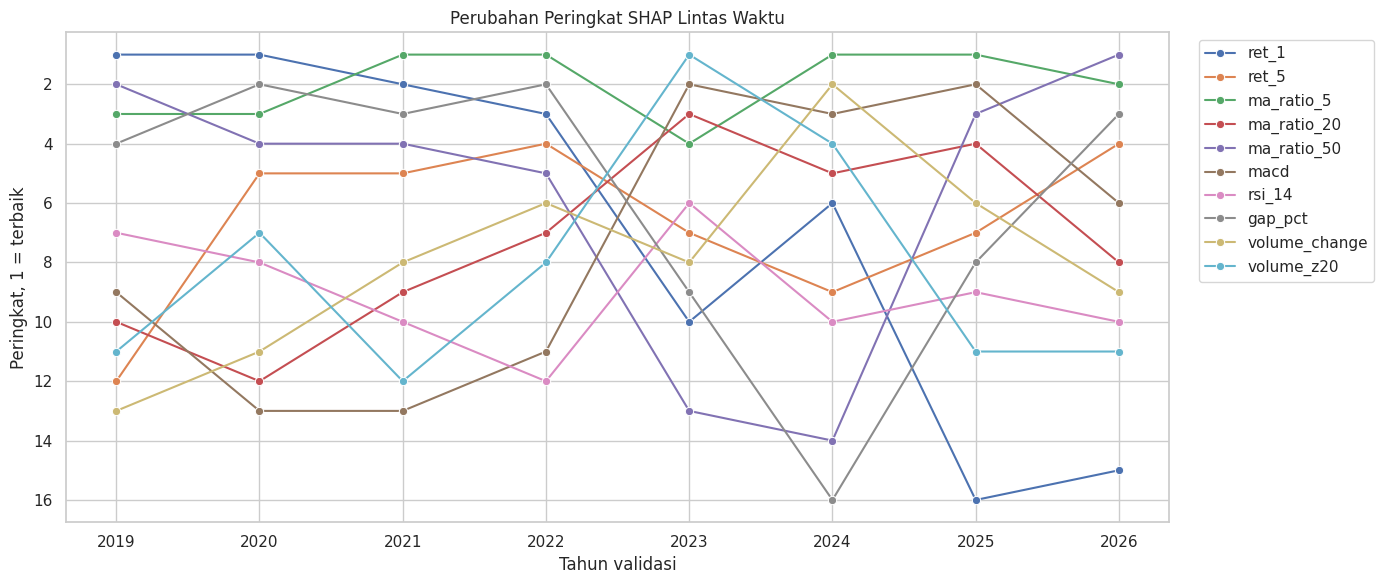

In [7]:
# Tahap 6: Peringkat SHAP per lipatan dan evaluasi Top-N
rank_rows, shap_rows, perf_rows, top_sets = [], [], [], {}
all_n = sorted(set([n for n in TOP_N_CANDIDATES if n <= len(FEATURES)] + [len(FEATURES)]))

for fold in folds:
    year = fold["year"]
    train, valid = data.loc[fold["train_idx"]], data.loc[fold["valid_idx"]]
    full_model, _, _ = train_eval(train, valid, FEATURES)
    imp = mean_abs_shap(full_model, train[FEATURES]).sort_values(ascending=False)
    ranks = imp.rank(ascending=False, method="average")
    for feature in FEATURES:
        rank_rows.append({"year": year, "feature": feature, "rank": ranks[feature]})
        shap_rows.append({"year": year, "feature": feature, "mean_abs_shap": imp[feature]})
    for n in all_n:
        selected = imp.head(n).index.tolist()
        top_sets[(year, n)] = set(selected)
        _, metrics, _ = train_eval(train, valid, selected)
        perf_rows.append({"year": year, "n_features": n, **metrics})

rank_df, shap_df, perf_df = map(pd.DataFrame, [rank_rows, shap_rows, perf_rows])
if rank_df.empty or shap_df.empty or perf_df.empty:
    raise RuntimeError("Hasil walk-forward kosong. Periksa data dan konfigurasi lipatan.")
rank_df["rank"] = pd.to_numeric(rank_df["rank"], errors="raise")
shap_df["mean_abs_shap"] = pd.to_numeric(
    shap_df["mean_abs_shap"], errors="raise"
)
display(rank_df.pivot(index="feature", columns="year", values="rank").round(1))

fig, ax = plt.subplots(figsize=(14, 6))
mean_rank_plot = (
    rank_df.groupby("feature", as_index=True)["rank"]
    .mean()
    .sort_values()
)
top_features_plot = mean_rank_plot.head(10).index.tolist()
rank_plot_df = rank_df[rank_df["feature"].isin(top_features_plot)].copy()
sns.lineplot(data=rank_plot_df, x="year", y="rank",
             hue="feature", marker="o", ax=ax)
ax.invert_yaxis(); ax.set(title="Perubahan Peringkat SHAP Lintas Waktu",
                          xlabel="Tahun validasi", ylabel="Peringkat, 1 = terbaik")
ax.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


,n_features,mean_auc,sd_auc,worst_auc,mean_bal_acc,mean_f1,folds,se_auc
0,4,0.4959,0.0349,0.4372,0.4861,0.5611,8,0.0124
1,6,0.4710,0.0315,0.4292,0.4944,0.5724,8,0.0111
2,8,0.4728,0.0326,0.4120,0.4717,0.5476,8,0.0115
3,10,0.4838,0.0313,0.4415,0.4875,0.5610,8,0.0111
4,12,0.4783,0.0350,0.4253,0.4845,0.5692,8,0.0124
5,19,0.4778,0.0331,0.4230,0.4862,0.5645,8,0.0117


Top-N robust menurut aturan satu galat baku: Top-4; ambang AUC = 0.4836


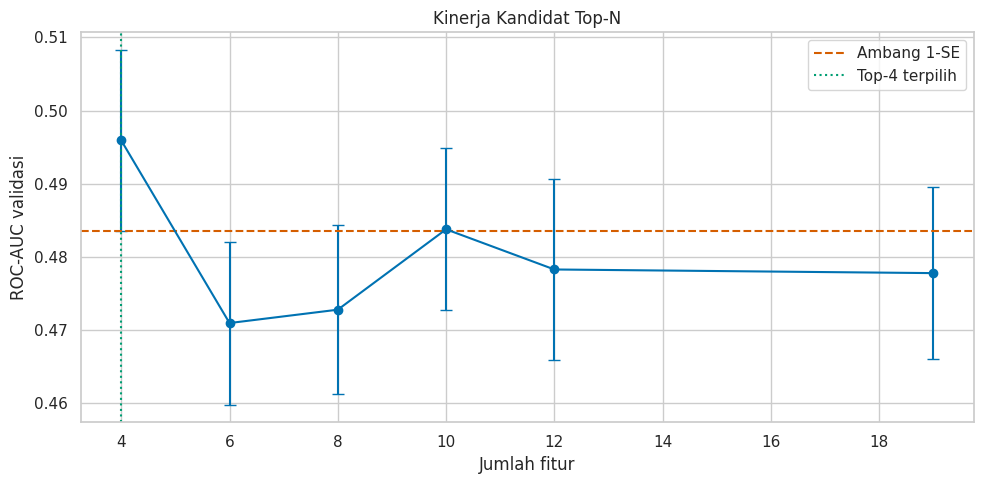

In [8]:
# Tahap 7: Pemilihan ukuran Top-N dengan aturan satu galat baku
agg = perf_df.groupby("n_features").agg(
    mean_auc=("auc","mean"), sd_auc=("auc","std"), worst_auc=("auc","min"),
    mean_bal_acc=("balanced_accuracy","mean"), mean_f1=("f1","mean"), folds=("year","count")
).reset_index()
agg["se_auc"] = agg.sd_auc / np.sqrt(agg.folds)
best = agg.loc[agg["mean_auc"].idxmax()]
threshold = float(best["mean_auc"] - best["se_auc"])
eligible = agg[agg["mean_auc"] >= threshold].sort_values(
    ["n_features", "worst_auc"], ascending=[True, False]
)
if eligible.empty:
    raise RuntimeError("Tidak ada kandidat Top-N yang memenuhi aturan satu galat baku.")
chosen_n = int(eligible.iloc[0]["n_features"])
display(agg.style.format({c:"{:.4f}" for c in agg.columns if c not in ["n_features","folds"]}))
print(f"Top-N robust menurut aturan satu galat baku: Top-{chosen_n}; ambang AUC = {threshold:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(
    agg["n_features"], agg["mean_auc"], yerr=agg["se_auc"],
    marker="o", capsize=4, color="#0072B2"
)
ax.axhline(threshold, ls="--", color="#D55E00", label="Ambang 1-SE")
ax.axvline(chosen_n, ls=":", color="#009E73", label=f"Top-{chosen_n} terpilih")
ax.set(title="Kinerja Kandidat Top-N", xlabel="Jumlah fitur", ylabel="ROC-AUC validasi")
ax.legend(); plt.tight_layout(); plt.show()


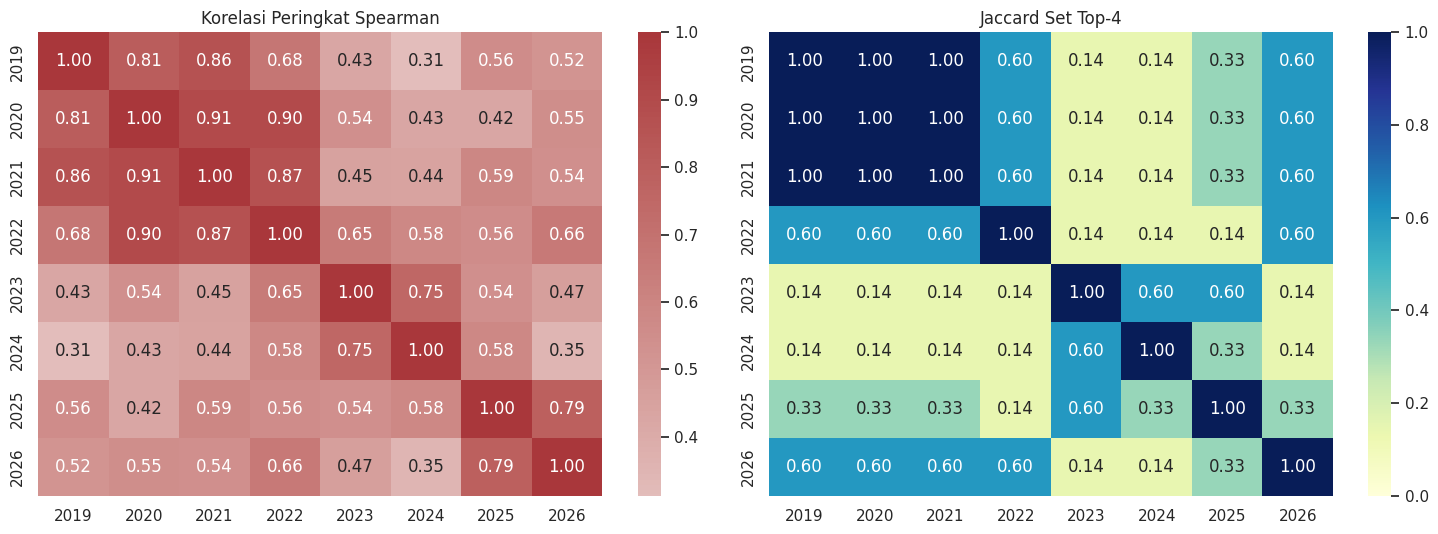

,frequency_top_n,mean_rank,mean_shap,shap_cv
ma_ratio_5,1.000,2.000,0.1215,0.2168
ma_ratio_50,0.625,5.750,0.0989,0.3456
gap_pct,0.625,5.875,0.1024,0.3707
ret_1,0.500,6.750,0.1132,0.5735
macd,0.375,7.375,0.0819,0.1887
ret_5,0.250,6.625,0.0925,0.2709
ma_ratio_20,0.250,7.250,0.0798,0.1685
volume_z20,0.250,8.125,0.0815,0.2500
volume_change,0.125,7.875,0.0780,0.1286
rsi_14,0.000,9.000,0.0781,0.2605


In [9]:
# Tahap 8: Spearman, Jaccard, frekuensi, dan kestabilan SHAP
rank_pivot = rank_df.pivot(index="feature", columns="year", values="rank")
years = rank_pivot.columns.tolist()
spearman = pd.DataFrame(np.eye(len(years)), index=years, columns=years)
jaccard = pd.DataFrame(np.eye(len(years)), index=years, columns=years)
for i, ya in enumerate(years):
    for j, yb in enumerate(years):
        if i < j:
            rho = spearmanr(rank_pivot[ya], rank_pivot[yb]).statistic
            A, B = top_sets[(ya, chosen_n)], top_sets[(yb, chosen_n)]
            jac = len(A & B) / len(A | B)
            spearman.loc[ya, yb] = spearman.loc[yb, ya] = rho
            jaccard.loc[ya, yb] = jaccard.loc[yb, ya] = jac

frequency = pd.Series({f: np.mean([f in top_sets[(y, chosen_n)] for y in years]) for f in FEATURES})
mean_rank = rank_df.groupby("feature")["rank"].mean()
shap_stats = shap_df.groupby("feature")["mean_abs_shap"].agg(["mean","std"])
shap_cv = (shap_stats["std"] / shap_stats["mean"].replace(0, np.nan)).fillna(shap_stats["std"].max())

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0])
axes[0].set_title("Korelasi Peringkat Spearman")
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Jaccard Set Top-{chosen_n}")
plt.tight_layout(); plt.show()

stability_table = pd.DataFrame({"frequency_top_n": frequency, "mean_rank": mean_rank,
                                "mean_shap": shap_stats["mean"], "shap_cv": shap_cv})
display(stability_table.sort_values(["frequency_top_n","mean_rank"], ascending=[False,True]).round(4))


year,2019,2020,2021,2022,2023,2024,2025,2026
feature,,,,,,,,
gap_pct,0.0058,0.0029,0.0178,0.0003,NaN,NaN,NaN,-0.0202
ma_ratio_20,NaN,NaN,NaN,NaN,-0.0240,NaN,0.0381,NaN
ma_ratio_5,0.0159,0.0291,-0.0153,-0.0542,0.0229,-0.0158,-0.0328,-0.0264
ma_ratio_50,0.0002,-0.0181,-0.0061,NaN,NaN,NaN,0.0089,-0.0043
macd,NaN,NaN,NaN,NaN,0.0353,0.0554,-0.0356,NaN
ret_1,0.0336,-0.0695,0.0274,-0.0252,NaN,NaN,NaN,NaN
ret_5,NaN,NaN,NaN,0.0117,NaN,NaN,NaN,0.0090
volume_change,NaN,NaN,NaN,NaN,NaN,0.0279,NaN,NaN
volume_z20,NaN,NaN,NaN,NaN,-0.0146,0.0204,NaN,NaN


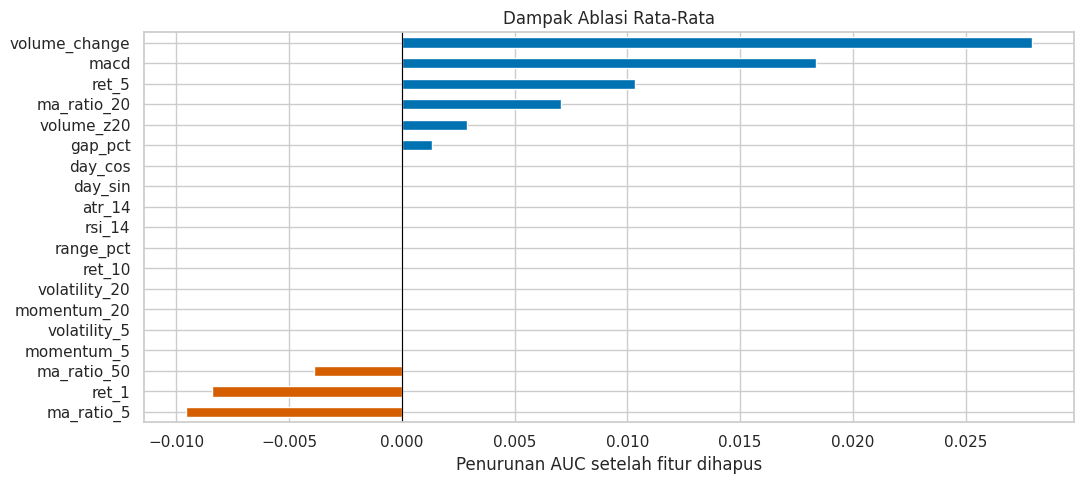

In [10]:
# Tahap 9: Uji ablasi pada blok validasi
# Kandidat dibatasi pada union Top-N agar komputasi tetap wajar dan relevan.
candidates = sorted(set().union(*[top_sets[(y, chosen_n)] for y in years]))
ablation_rows = []
for fold in folds:
    year = fold["year"]
    train, valid = data.loc[fold["train_idx"]], data.loc[fold["valid_idx"]]
    base_features = sorted(top_sets[(year, chosen_n)])
    _, base_metrics, _ = train_eval(train, valid, base_features)
    for feature in base_features:
        reduced = [f for f in base_features if f != feature]
        _, reduced_metrics, _ = train_eval(train, valid, reduced)
        ablation_rows.append({"year": year, "feature": feature,
                              "delta_auc": base_metrics["auc"] - reduced_metrics["auc"]})
ablation_df = pd.DataFrame(ablation_rows)
ablation_mean = (
    ablation_df.groupby("feature")["delta_auc"]
    .mean().reindex(FEATURES).fillna(0)
)

display(ablation_df.pivot(index="feature", columns="year", values="delta_auc").round(4))
fig, ax = plt.subplots(figsize=(11, 5))
ablation_mean.sort_values().plot.barh(ax=ax, color=np.where(ablation_mean.sort_values()>=0,"#0072B2","#D55E00"))
ax.axvline(0, color="black", lw=.8); ax.set(title="Dampak Ablasi Rata-Rata",
                                             xlabel="Penurunan AUC setelah fitur dihapus", ylabel="")
plt.tight_layout(); plt.show()


,frequency,rank_score,stability_score,ablation_score,robust_score,mean_rank,shap_cv,mean_delta_auc
ma_ratio_5,1.000,0.9444,0.8017,0.0000,0.6965,2.000,0.2168,-0.0096
volume_change,0.125,0.6181,1.0000,1.0000,0.6420,7.875,0.1286,0.0279
macd,0.375,0.6458,0.8650,0.6577,0.6114,7.375,0.1887,0.0184
ma_ratio_20,0.250,0.6528,0.9102,0.2524,0.4833,7.250,0.1685,0.0070
ret_5,0.250,0.6875,0.6800,0.3702,0.4754,6.625,0.2709,0.0103
ma_ratio_50,0.625,0.7361,0.5121,0.0000,0.4739,5.750,0.3456,-0.0039
gap_pct,0.625,0.7292,0.4559,0.0480,0.4730,5.875,0.3707,0.0013
volume_z20,0.250,0.6042,0.7270,0.1037,0.3974,8.125,0.2500,0.0029
ret_1,0.500,0.6806,0.0000,0.0000,0.3201,6.750,0.5735,-0.0084
rsi_14,0.000,0.5556,0.7034,0.0000,0.2796,9.000,0.2605,0.0000


FITUR FINAL: ['ma_ratio_5', 'volume_change', 'macd', 'ma_ratio_20']
Pasangan korelasi absolut >= 0,90: Tidak ada


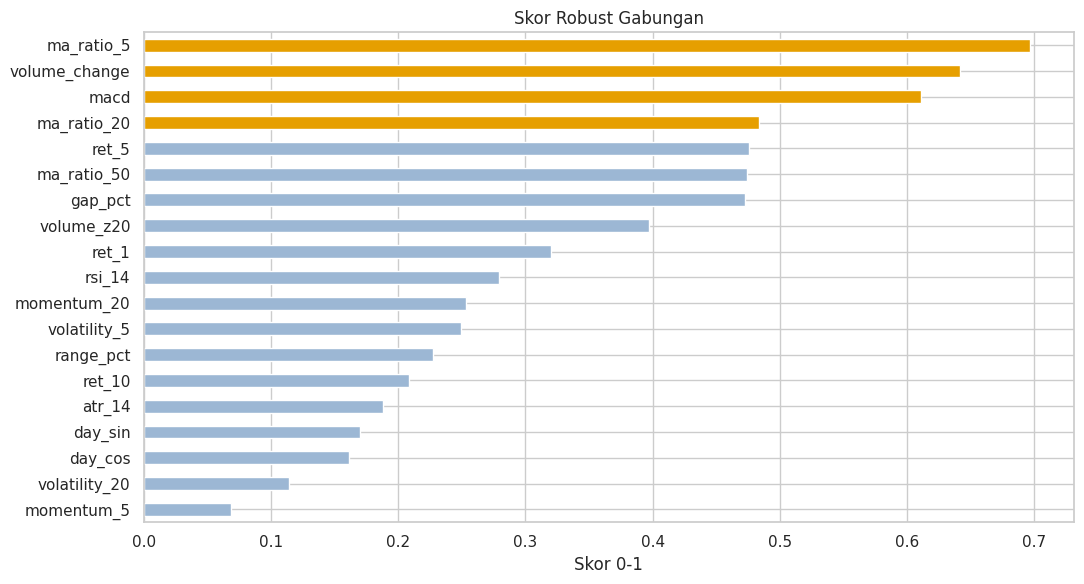

In [11]:
# Tahap 10: Skor gabungan dan set fitur final
def minmax_good_high(s):
    s = s.astype(float)
    return (s-s.min())/(s.max()-s.min()) if s.max() > s.min() else pd.Series(1.0, index=s.index)

score = pd.DataFrame(index=FEATURES)
score["frequency"] = frequency
score["rank_score"] = 1 - (mean_rank-1)/(len(FEATURES)-1)
score["stability_score"] = 1 - minmax_good_high(shap_cv)
score["ablation_score"] = minmax_good_high(ablation_mean.clip(lower=0))
score["robust_score"] = (
    WEIGHTS["frequency"] * score["frequency"] +
    WEIGHTS["rank"] * score["rank_score"] +
    WEIGHTS["stability"] * score["stability_score"] +
    WEIGHTS["ablation"] * score["ablation_score"]
)
score["mean_rank"] = mean_rank
score["shap_cv"] = shap_cv
score["mean_delta_auc"] = ablation_mean
score = score.sort_values("robust_score", ascending=False)

# Jumlah final mengikuti chosen_n. Pemeriksaan korelasi memberi peringatan, bukan penghapusan otomatis.
FINAL_FEATURES = score.head(chosen_n).index.tolist()
train_corr = data.loc[folds[-1]["train_idx"], FINAL_FEATURES].corr().abs()
high_corr = [(a,b,train_corr.loc[a,b]) for i,a in enumerate(FINAL_FEATURES)
             for b in FINAL_FEATURES[i+1:] if train_corr.loc[a,b] >= 0.90]
display(score.round(4))
print("FITUR FINAL:", FINAL_FEATURES)
print("Pasangan korelasi absolut >= 0,90:", high_corr if high_corr else "Tidak ada")

fig, ax = plt.subplots(figsize=(11, 6))
sorted_scores = score["robust_score"].sort_values()
sorted_scores.plot.barh(
    ax=ax,
    color=["#9CB7D4" if f not in FINAL_FEATURES else "#E69F00"
           for f in sorted_scores.index]
)
ax.set(title="Skor Robust Gabungan", xlabel="Skor 0-1", ylabel="")
plt.tight_layout(); plt.show()


,year,auc,balanced_accuracy,f1
0,2019,0.5005,0.5178,0.5915
1,2020,0.5137,0.4991,0.5806
2,2021,0.4615,0.4945,0.5793
3,2022,0.4667,0.4621,0.5517
4,2023,0.5243,0.5229,0.6050
5,2024,0.5359,0.5030,0.5776
6,2025,0.4640,0.4716,0.5515
7,2026,0.4171,0.4668,0.5229


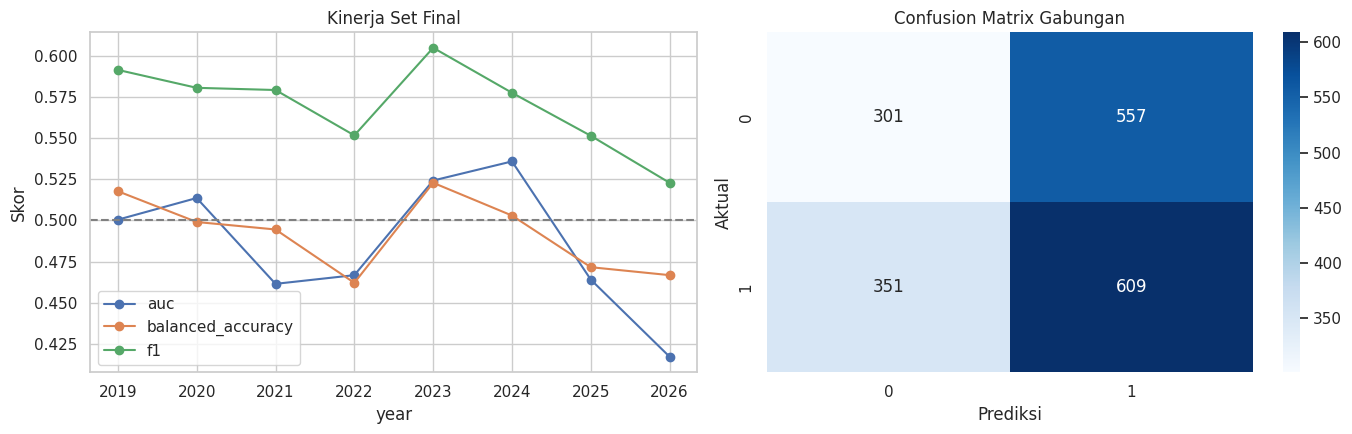

In [12]:
# Tahap 11: Uji ulang set final lintas periode
final_rows, all_prob, all_true = [], [], []
for fold in folds:
    train, valid = data.loc[fold["train_idx"]], data.loc[fold["valid_idx"]]
    _, metrics, proba = train_eval(train, valid, FINAL_FEATURES)
    final_rows.append({"year": fold["year"], **metrics})
    all_prob.extend(proba)
    all_true.extend(valid["target"])
final_perf = pd.DataFrame(final_rows)
display(final_perf.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
final_perf.set_index("year")[["auc","balanced_accuracy","f1"]].plot(marker="o", ax=axes[0])
axes[0].axhline(.5, ls="--", color="gray"); axes[0].set(title="Kinerja Set Final", ylabel="Skor")
cm = confusion_matrix(all_true, np.asarray(all_prob)>=.5)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set(title="Confusion Matrix Gabungan", xlabel="Prediksi", ylabel="Aktual")
plt.tight_layout(); plt.show()


In [13]:
# Tahap 12: Analisis khusus 2022 versus 2024
focus_years = [y for y in [2022, 2024] if y in years]
if len(focus_years) == 2:
    comparison = rank_pivot[focus_years].copy()
    comparison["perubahan_absolut"] = (comparison[2024]-comparison[2022]).abs()
    comparison = comparison.sort_values("perubahan_absolut", ascending=False)
    display(comparison.round(1))
    rho = spearman.loc[2022, 2024]
    jac = jaccard.loc[2022, 2024]
    print(f"Spearman 2022-2024 = {rho:.3f}; Jaccard Top-{chosen_n} = {jac:.3f}")
else:
    print("Data belum mencakup kedua tahun 2022 dan 2024. Analisis lintas tahun tetap tersedia pada tahap 8.")


year,2022,2024,perubahan_absolut
feature,,,
gap_pct,2.0,16.0,14.0
ma_ratio_50,5.0,14.0,9.0
macd,11.0,3.0,8.0
volatility_5,13.0,8.0,5.0
ret_5,4.0,9.0,5.0
atr_14,15.0,11.0,4.0
volume_change,6.0,2.0,4.0
volume_z20,8.0,4.0,4.0
range_pct,9.0,12.0,3.0


Spearman 2022-2024 = 0.581; Jaccard Top-4 = 0.143


In [14]:
# Tahap 13: Audit bug, logika, dan risiko metodologis
checks = []
checks.append(("Tanggal berurutan", data.index.is_monotonic_increasing))
checks.append(("Tidak ada duplikasi tanggal", not data.index.duplicated().any()))
checks.append(("Tidak ada NaN/Inf", np.isfinite(data[FEATURES].to_numpy()).all()))
checks.append(("Train selalu sebelum validasi", all(data.index[f["train_idx"]].max() < data.index[f["valid_idx"]].min() for f in folds)))
checks.append(("SHAP memakai train tail", True))
checks.append(("Minimal tiga lipatan", len(folds) >= 3))
audit = pd.DataFrame(checks, columns=["Pemeriksaan", "Lulus"])
display(audit)
if not audit["Lulus"].all():
    raise AssertionError("Audit gagal. Periksa tahap yang bernilai False.")

display(Markdown(f"""
### Memo Pertanggungjawaban Desain

Set fitur final adalah **{', '.join(FINAL_FEATURES)}**. Pemilihan memakai {len(folds)} lipatan *walk-forward*, Top-{chosen_n}, stabilitas peringkat, variasi SHAP, dan dampak ablasi. Desain ini lebih tangguh daripada memilih fitur terbaik dari satu tahun karena setiap fitur harus berulang kali berguna pada kondisi waktu berbeda. Volatilitas dan momentum dapat dipertahankan bersama jika skor robust mendukung keduanya serta korelasi tidak menunjukkan redundansi berlebihan.

Hasil tetap memiliki keterbatasan. SHAP menjelaskan kontribusi prediktif dalam XGBoost dan tidak membuktikan sebab ekonomi. Nilainya sensitif terhadap panjang jendela, hiperparameter, sampel latar, korelasi fitur, dan perubahan struktur pasar. Ablasi dapat mengecil ketika fitur pengganti membawa informasi serupa. AUC yang sedikit di atas 0,50 belum menjamin keuntungan setelah biaya transaksi. Model perlu diuji dengan biaya, *turnover*, *drawdown*, dan data baru. Pelatihan ulang sebaiknya dilakukan secara berkala atau saat Spearman dan Jaccard turun tajam.
"""))


,Pemeriksaan,Lulus
0,Tanggal berurutan,True
1,Tidak ada duplikasi tanggal,True
2,Tidak ada NaN/Inf,True
3,Train selalu sebelum validasi,True
4,SHAP memakai train tail,True
5,Minimal tiga lipatan,True



### Memo Pertanggungjawaban Desain

Set fitur final adalah **ma_ratio_5, volume_change, macd, ma_ratio_20**. Pemilihan memakai 8 lipatan *walk-forward*, Top-4, stabilitas peringkat, variasi SHAP, dan dampak ablasi. Desain ini lebih tangguh daripada memilih fitur terbaik dari satu tahun karena setiap fitur harus berulang kali berguna pada kondisi waktu berbeda. Volatilitas dan momentum dapat dipertahankan bersama jika skor robust mendukung keduanya serta korelasi tidak menunjukkan redundansi berlebihan.

Hasil tetap memiliki keterbatasan. SHAP menjelaskan kontribusi prediktif dalam XGBoost dan tidak membuktikan sebab ekonomi. Nilainya sensitif terhadap panjang jendela, hiperparameter, sampel latar, korelasi fitur, dan perubahan struktur pasar. Ablasi dapat mengecil ketika fitur pengganti membawa informasi serupa. AUC yang sedikit di atas 0,50 belum menjamin keuntungan setelah biaya transaksi. Model perlu diuji dengan biaya, *turnover*, *drawdown*, dan data baru. Pelatihan ulang sebaiknya dilakukan secara berkala atau saat Spearman dan Jaccard turun tajam.


In [15]:
# Tahap 14: Ekspor seluruh luaran tabel
with pd.ExcelWriter("hasil_seleksi_fitur_ihsg.xlsx") as writer:
    fold_table.to_excel(writer, "lipatan", index=False)
    rank_df.to_excel(writer, "peringkat", index=False)
    shap_df.to_excel(writer, "nilai_shap", index=False)
    perf_df.to_excel(writer, "kinerja_top_n", index=False)
    stability_table.to_excel(writer, "stabilitas")
    spearman.to_excel(writer, "spearman")
    jaccard.to_excel(writer, "jaccard")
    ablation_df.to_excel(writer, "ablasi", index=False)
    score.to_excel(writer, "skor_robust")
    final_perf.to_excel(writer, "kinerja_final", index=False)

pd.DataFrame({"File output": ["hasil_seleksi_fitur_ihsg.xlsx"],
              "Isi": ["Peringkat, SHAP, stabilitas, ablasi, skor robust, dan kinerja final"]})


,File output,Isi
0,hasil_seleksi_fitur_ihsg.xlsx,"Peringkat, SHAP, stabilitas, ablasi, skor robu..."


## Cara Membaca Hasil

- **Spearman tinggi** berarti urutan seluruh fitur relatif konsisten.
- **Jaccard tinggi** berarti anggota Top-N serupa antartahun.
- **Frequency tinggi** berarti fitur sering masuk Top-N.
- **SHAP CV rendah** berarti besaran kontribusi lebih stabil.
- **Delta AUC ablasi positif** berarti AUC turun ketika fitur dihapus.
- **Robust score tinggi** berarti fitur kuat menurut beberapa bukti sekaligus.

Keputusan ilmiah tidak boleh hanya mengikuti satu angka. Periksa juga periode terburuk, redundansi, keseimbangan kelas, dan manfaat ekonomi setelah biaya transaksi.
